In [9]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder

In [10]:
df = pd.read_csv('loanapproval.csv')
label_encoder = LabelEncoder()

In [11]:
df.head()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status,loan_approved
0,1,59,Male,Divorced,100073,7169,793,1,1,Unemployed,1
1,2,49,Male,Married,112197,23556,789,0,2,Employed,1
2,3,35,Male,Divorced,84429,27052,372,1,4,Unemployed,0
3,4,63,Female,Single,124195,11313,808,3,4,Self-employed,1
4,5,28,Female,Married,81627,13315,689,0,1,Unemployed,1


In [12]:
df.columns

Index(['applicant_id', 'age', 'gender', 'marital_status', 'annual_income',
       'loan_amount', 'credit_score', 'num_dependents', 'existing_loans_count',
       'employment_status', 'loan_approved'],
      dtype='str')

In [13]:
df.isnull().sum()

applicant_id            0
age                     0
gender                  0
marital_status          0
annual_income           0
loan_amount             0
credit_score            0
num_dependents          0
existing_loans_count    0
employment_status       0
loan_approved           0
dtype: int64

In [14]:
df.describe()

,applicant_id,age,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,loan_approved
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.000000,1000.000000
mean,500.500000,42.515000,81972.972000,27244.866000,576.125000,1.97700,2.042000,0.729000
std,288.819436,12.611059,37547.255418,12822.752877,155.921483,1.41862,1.413589,0.444699
min,1.000000,21.000000,20155.000000,5082.000000,300.000000,0.00000,0.000000,0.000000
25%,250.750000,32.000000,48913.250000,16587.500000,443.750000,1.00000,1.000000,0.000000
50%,500.500000,43.000000,82050.000000,27041.500000,573.500000,2.00000,2.000000,1.000000
75%,750.250000,53.000000,113556.000000,37939.250000,713.250000,3.00000,3.000000,1.000000
max,1000.000000,64.000000,149951.000000,49864.000000,849.000000,4.00000,4.000000,1.000000


In [16]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype
---  ------                --------------  -----
 0   applicant_id          1000 non-null   int64
 1   age                   1000 non-null   int64
 2   gender                1000 non-null   str  
 3   marital_status        1000 non-null   str  
 4   annual_income         1000 non-null   int64
 5   loan_amount           1000 non-null   int64
 6   credit_score          1000 non-null   int64
 7   num_dependents        1000 non-null   int64
 8   existing_loans_count  1000 non-null   int64
 9   employment_status     1000 non-null   str  
 10  loan_approved         1000 non-null   int64
dtypes: int64(8), str(3)
memory usage: 107.9 KB


In [17]:
df['gender'] = label_encoder.fit_transform(df['gender'])
df['marital_status'] = label_encoder.fit_transform(df['marital_status'])
df['employment_status'] = label_encoder.fit_transform(df['employment_status'])

In [19]:
correlation = df.drop('loan_approved',axis=1)
correlation.corr()

,applicant_id,age,gender,marital_status,annual_income,loan_amount,credit_score,num_dependents,existing_loans_count,employment_status
applicant_id,1.000000,-0.041905,-0.010904,0.003483,0.075261,0.013564,-0.027069,-0.085307,-0.000201,0.037934
age,-0.041905,1.000000,-0.040327,-0.052426,0.002591,0.000235,0.052769,-0.031510,0.063977,0.017699
gender,-0.010904,-0.040327,1.000000,-0.078468,0.010925,-0.017831,0.013536,-0.032406,0.034001,-0.005564
marital_status,0.003483,-0.052426,-0.078468,1.000000,-0.038886,0.023516,-0.003239,-0.026466,0.027671,-0.014520
annual_income,0.075261,0.002591,0.010925,-0.038886,1.000000,-0.024862,0.016921,-0.016445,-0.010745,0.040909
loan_amount,0.013564,0.000235,-0.017831,0.023516,-0.024862,1.000000,0.044939,0.037140,-0.012043,-0.016806
credit_score,-0.027069,0.052769,0.013536,-0.003239,0.016921,0.044939,1.000000,-0.067063,0.017398,-0.053793
num_dependents,-0.085307,-0.031510,-0.032406,-0.026466,-0.016445,0.037140,-0.067063,1.000000,0.046405,-0.040916
existing_loans_count,-0.000201,0.063977,0.034001,0.027671,-0.010745,-0.012043,0.017398,0.046405,1.000000,-0.003003
employment_status,0.037934,0.017699,-0.005564,-0.014520,0.040909,-0.016806,-0.053793,-0.040916,-0.003003,1.000000


# Correlation

<Axes: >

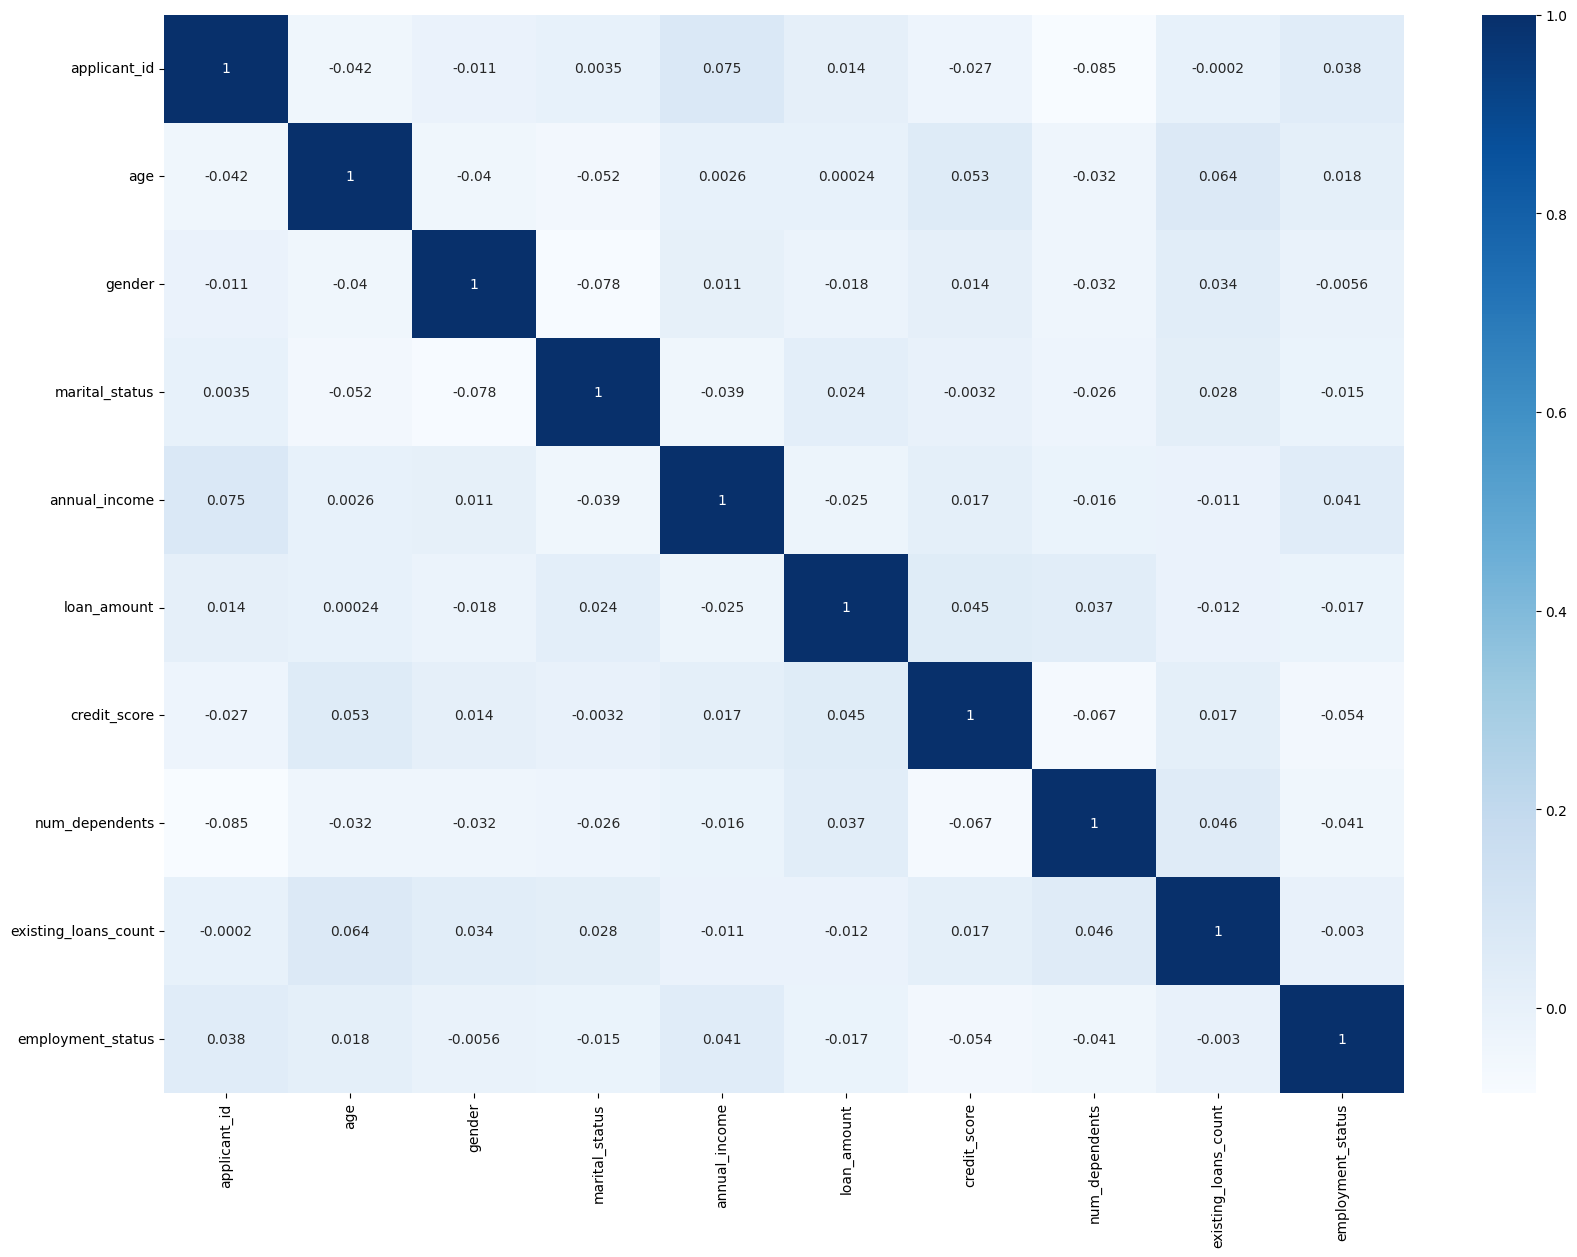

In [25]:
plt.figure(figsize=(20,14))

sns.heatmap(correlation.corr(),annot=True,cmap='Blues')

# Number of lons approved vs not approved

In [27]:
# counts = df['loan_approved'].value_counts()
# plt.bar(counts.index, counts.values)
# plt.show()

df['loan_approved']

0      1
1      1
2      0
3      1
4      1
      ..
995    1
996    1
997    1
998    1
999    1
Name: loan_approved, Length: 1000, dtype: int64

Text(0, 0.5, 'Number of loan approved')

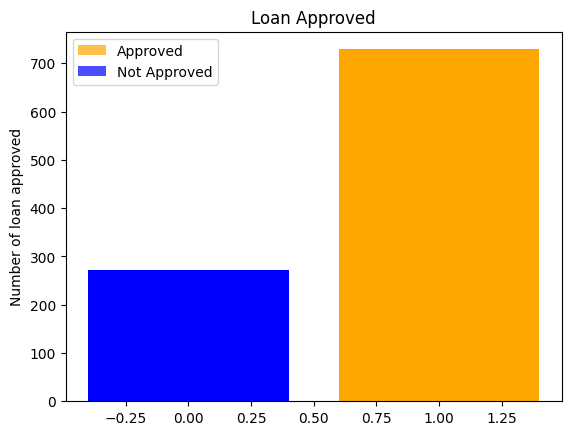

In [36]:
for approval in df['loan_approved'].unique() :
    subset = df[df['loan_approved'] == approval]
    if approval == 1:
        color = 'orange'
        label = 'Approved'
    else:
        color = 'blue'
        label = 'Not Approved'
    plt.bar(subset['loan_approved'], subset['loan_approved'].value_counts(), color=color, label=label, alpha=0.7)
plt.title("Loan Approved")
plt.legend()
plt.ylabel("Number of loan approved")
# plt.xlabel("ID")